# Paper analysis - tables & figures

Loads every run under `results/` and reproduces the final paper's numbers and figures:

- **Table IV** (scope x tier), **Table V** (strategy x tier), **Table VI** (model, zero+RAG pooled)
- RQ1 paired tests + TOST equivalence; RQ2 zero-vs-RAG test, reasoning cluster-bootstrap CIs, SFT guess-signature; RQ3 CWE/language slices
- Figures: `results_rq2eff.pdf` (efficiency plane), `results_rq3cwe.pdf` (CWE heatmaps), `results_rq3lang.pdf` (language P-C), `token_statistics.png`

Run all cells top to bottom.

In [1]:
# 0. config + loaders
import glob, json, math, random
import numpy as np, pandas as pd
from collections import defaultdict
from pathlib import Path

MODELS = ["qwen3-30b-instruct","qwen3-30b-thinking","mistral-small:24b",
          "magistral-small:24b","nemotron-nano:12b","nemotron-nano-think:12b"]
REASONING = {"qwen3-30b-thinking","magistral-small:24b","nemotron-nano-think:12b"}
ORG = {"qwen3-30b-instruct":"qwen","qwen3-30b-thinking":"qwen",
       "mistral-small:24b":"mistral","magistral-small:24b":"mistral",
       "nemotron-nano:12b":"nemotron","nemotron-nano-think:12b":"nemotron"}
STRATS = ["zero","rag","sft"]
SCOPES = ["function","file","repository"]
TIERS  = ["SFSF","MFSF","MFMF"]
BENCH  = "FuncFileRepo.test"

def load_results():
    rows=[]
    for m in MODELS:
        for s in STRATS:
            for f in sorted(glob.glob(f"results/{m}/{s}/{BENCH}_*.jsonl")):
                t=int(Path(f).stem.rsplit("_",1)[1])
                for line in open(f):
                    r=json.loads(line); r["model"]=m; r["trial"]=t; rows.append(r)
    df=pd.DataFrame(rows)
    df["pair"]=(df["id"]+1)//2
    return df

META = {r["id"]:{"cwe_id":r.get("cwe_id"),"cvss":r.get("cvss"),"project":r.get("project")}
        for r in map(json.loads, open(f"data/{BENCH}.jsonl"))}
df = load_results()
for k in ("cwe_id","cvss"):
    df[k]=df["id"].map(lambda i: META[i][k])
print(df.shape); df.groupby(["model","prompts"])["trial"].nunique()

(155520, 14)


model                    prompts
magistral-small:24b      rag        3
                         sft        3
                         zero       3
mistral-small:24b        rag        3
                         sft        3
                         zero       3
nemotron-nano-think:12b  rag        3
                         sft        3
                         zero       3
nemotron-nano:12b        rag        3
                         sft        3
                         zero       3
qwen3-30b-instruct       rag        3
                         sft        3
                         zero       3
qwen3-30b-thinking       rag        3
                         sft        3
                         zero       3
Name: trial, dtype: int64

In [2]:
# 1. metric helpers — 8 metrics over a slice (pairs grouped within scope)
def metrics8(g: pd.DataFrame) -> dict:
    g=g.dropna(subset=["predict"])
    yp=g["predict"].astype(bool).astype(int).to_numpy()
    yt=g["label"].astype(bool).astype(int).to_numpy()
    TP=int(((yp==1)&(yt==1)).sum()); TN=int(((yp==0)&(yt==0)).sum())
    FP=int(((yp==1)&(yt==0)).sum()); FN=int(((yp==0)&(yt==1)).sum())
    acc=(TP+TN)/max(len(yt),1); pre=TP/max(TP+FP,1); rec=TP/max(TP+FN,1)
    f1=2*pre*rec/max(pre+rec,1e-9)
    c=v=b=r=tot=0
    # a pair-instance is one (model, strategy, trial, scope, pair) condition —
    # grouping by scope+pair alone would let later models overwrite earlier ones
    keys=[k for k in ("model","prompts","trial","scope") if k in g.columns]+["pair"]
    for _,dd in g.groupby(keys):
        lab=dict(zip(dd["label"].astype(bool), dd["predict"].astype(bool)))
        if True in lab and False in lab:
            tot+=1; a,bn=lab[True],lab[False]
            c+=(a and not bn); v+=(a and bn); b+=((not a) and (not bn)); r+=((not a) and bn)
    z=max(tot,1)
    return dict(PC=c/z,PV=v/z,PB=b/z,PR=r/z,Acc=acc,Pre=pre,Rec=rec,F1=f1,
                q=yp.mean() if len(yp) else float("nan"), pairs=tot, n=len(yt))

def trial_mean(sub: pd.DataFrame, keys=("PC","PV","PB","PR","Acc","Pre","Rec","F1")):
    if not len(sub):
        nan={k:float("nan") for k in keys}
        return nan, dict(nan), []
    per=[metrics8(sub[sub.trial==t]) for t in sorted(sub.trial.unique())]
    mu={k:np.mean([p[k] for p in per]) for k in keys}
    sd={k:np.std([p[k] for p in per]) for k in keys}
    return mu, sd, per

def fmt(mu, keys=("PC","PV","PB","PR","Acc","Pre","Rec","F1")):
    return " & ".join(f"{mu[k]:.3f}".lstrip("0") for k in keys)

In [3]:
# 2. Table IV (RQ1): scope x (mean|tier), ALL strategies pooled (matches printed caption)
zr = df[df.prompts.isin(["zero","rag"])]
print("scope tier  " + " ".join(f"{k:>6}" for k in ("PC","PV","PB","PR","Acc","Pre","Rec","F1")))
tab4={}
for sc in SCOPES:
    for tier in ["mean"]+TIERS:
        sub = df[df.scope==sc] if tier=="mean" else df[(df.scope==sc)&(df.complexity==tier)]
        mu,sd,_ = trial_mean(sub)
        tab4[(sc,tier)]=mu
        print(f"{sc:<10}{tier:<6}" + " ".join(f"{mu[k]:.3f}" for k in ("PC","PV","PB","PR","Acc","Pre","Rec","F1")))
# LaTeX rows (bold to be applied manually per table caption rule)
for sc in SCOPES:
    for tier in ["mean"]+TIERS:
        print(f"% {sc[:4]:<5} {tier:<5} & " + fmt(tab4[(sc,tier)]) + " \\\\")

scope tier      PC     PV     PB     PR    Acc    Pre    Rec     F1
function  mean  0.202 0.359 0.292 0.147 0.528 0.526 0.561 0.543
function  SFSF  0.193 0.403 0.263 0.142 0.525 0.522 0.596 0.557
function  MFSF  0.178 0.338 0.313 0.171 0.503 0.503 0.516 0.509
function  MFMF  0.225 0.329 0.308 0.138 0.544 0.543 0.555 0.549
file      mean  0.205 0.299 0.352 0.144 0.530 0.532 0.504 0.518
file      SFSF  0.200 0.317 0.335 0.148 0.526 0.527 0.517 0.522
file      MFSF  0.180 0.277 0.394 0.149 0.516 0.518 0.457 0.485
file      MFMF  0.223 0.296 0.343 0.138 0.543 0.545 0.519 0.532
repositorymean  0.195 0.330 0.328 0.147 0.524 0.524 0.525 0.524
repositorySFSF  0.190 0.374 0.293 0.144 0.523 0.521 0.563 0.542
repositoryMFSF  0.180 0.295 0.364 0.162 0.509 0.509 0.474 0.491
repositoryMFMF  0.209 0.310 0.340 0.141 0.534 0.535 0.518 0.526
% func  mean  & .202 & .359 & .292 & .147 & .528 & .526 & .561 & .543 \\
% func  SFSF  & .193 & .403 & .263 & .142 & .525 & .522 & .596 & .557 \\
% func  MFSF  & .1

In [4]:
# 3. RQ1 stats: per-model paired tests (func->file / func->repo) + trial noise
from scipy import stats as sps
MS={}
for m in MODELS:
    for sc in SCOPES:
        mu,_,_ = trial_mean(zr[(zr.model==m)&(zr.scope==sc)])
        MS[(m,sc)]=mu
for k in ("PC","PV","PB","Rec","F1"):
    for a,b,lab in [("function","file","func->file"),("function","repository","func->repo")]:
        d=[MS[(m,b)][k]-MS[(m,a)][k] for m in MODELS]
        t,p=sps.ttest_rel([MS[(m,b)][k] for m in MODELS],[MS[(m,a)][k] for m in MODELS])
        dz=np.mean(d)/np.std(d,ddof=1)
        print(f"{k:<4}{lab:<12} delta={np.mean(d):+.3f}  p={p:.3f}  dz={dz:+.2f}")
# trial-to-trial std across Table IV cells
stds=[]
for sc in SCOPES:
    for tier in ["mean"]+TIERS:
        sub = zr[zr.scope==sc] if tier=="mean" else zr[(zr.scope==sc)&(zr.complexity==tier)]
        _,sd,_ = trial_mean(sub); stds += list(sd.values())
print(f"trial std: median={np.median(stds):.4f} max={max(stds):.4f}")

# TOST equivalence (pre-declared margin 0.05; also 0.03) on the same paired diffs
from scipy import stats as sps
def tost(diffs,delta):
    d=np.array(diffs); n=len(d); mean=d.mean(); se=d.std(ddof=1)/np.sqrt(n)
    return mean,max(1-sps.t.cdf((mean+delta)/se,n-1),1-sps.t.cdf((delta-mean)/se,n-1))
for a,b,lab in [("function","file","func->file"),("function","repository","func->repo")]:
    dfs=[MS[(m,b)]["PC"]-MS[(m,a)]["PC"] for m in MODELS]
    for delta in (0.03,0.05):
        mean,p=tost(dfs,delta); print(f"TOST {lab} d={delta}: mean={mean:+.4f} pTOST={p:.4f}")
zz={m:trial_mean(df[(df.model==m)&(df.prompts=="zero")])[0]["PC"] for m in MODELS}
rr={m:trial_mean(df[(df.model==m)&(df.prompts=="rag")])[0]["PC"] for m in MODELS}
for delta in (0.03,0.05):
    mean,p=tost([rr[m]-zz[m] for m in MODELS],delta); print(f"TOST zero->rag d={delta}: mean={mean:+.4f} pTOST={p:.4f}")
# Table rq1zr: per-scope mean +- SD across models (zr pooled)
for sc in SCOPES:
    vals={k:[MS[(m,sc)][k] for m in MODELS] for k in ("PC","PV","PB","PR")}
    print(sc," & ".join(f"{np.mean(vals[k]):.3f} $\\pm$ {np.std(vals[k],ddof=1):.3f}" for k in ("PC","PV","PB","PR")))

PC  func->file   delta=+0.002  p=0.731  dz=+0.15
PC  func->repo   delta=-0.009  p=0.199  dz=-0.60
PV  func->file   delta=-0.081  p=0.007  dz=-1.82
PV  func->repo   delta=-0.046  p=0.011  dz=-1.61
PB  func->file   delta=+0.088  p=0.016  dz=+1.47
PB  func->repo   delta=+0.054  p=0.000  dz=+5.02
Rec func->file   delta=-0.079  p=0.017  dz=-1.44
Rec func->repo   delta=-0.055  p=0.002  dz=-2.55
F1  func->file   delta=-0.034  p=0.021  dz=-1.36
F1  func->repo   delta=-0.029  p=0.000  dz=-3.26
trial std: median=0.0035 max=0.0105
TOST func->file d=0.03: mean=+0.0024 pTOST=0.0045
TOST func->file d=0.05: mean=+0.0024 pTOST=0.0004
TOST func->repo d=0.03: mean=-0.0089 pTOST=0.0085
TOST func->repo d=0.05: mean=-0.0089 pTOST=0.0005
TOST zero->rag d=0.03: mean=-0.0057 pTOST=0.0335
TOST zero->rag d=0.05: mean=-0.0057 pTOST=0.0040
function 0.194 $\pm$ 0.096 & 0.340 $\pm$ 0.095 & 0.355 $\pm$ 0.145 & 0.111 $\pm$ 0.046
file 0.196 $\pm$ 0.083 & 0.259 $\pm$ 0.084 & 0.442 $\pm$ 0.126 & 0.103 $\pm$ 0.052
reposi

In [5]:
# 4. Table V (tab:rq1strat: strategy x tier, scopes pooled) + Table VI (tab:rq2: model, zero+RAG pooled)
KP=("Acc","Pre","Rec","F1","PC","PV","PB","PR")   # paper column order: Classification | Pair-wise
def row(mu): return " & ".join(f"{mu[k]:.3f}".lstrip("0") for k in KP)

print("== Table V - by prompting strategy x complexity tier (scopes/models/trials pooled) ==")
for s in STRATS:
    for tier in ["mean"]+TIERS:
        sub = df[df.prompts==s] if tier=="mean" else df[(df.prompts==s)&(df.complexity==tier)]
        print(f"  {s:<5} {tier:<5} & " + row(trial_mean(sub)[0]) + " \\\\")

print("\n== Table VI - by model (zero-shot and RAG pooled) + group means ==")
zr = df[df.prompts.isin(["zero","rag"])]
for m in MODELS:
    print(f"  {m:<26} & " + row(trial_mean(zr[zr.model==m])[0]) + " \\\\")
for lab, grp in (("Direct", ~zr.model.isin(REASONING)), ("Reasoning", zr.model.isin(REASONING))):
    print(f"  {lab:<26} & " + row(trial_mean(zr[grp])[0]) + " \\\\")


== Table V - by prompting strategy x complexity tier (scopes/models/trials pooled) ==
  zero  mean  & .540 & .537 & .583 & .559 & .194 & .389 & .303 & .114 \\
  zero  SFSF  & .539 & .534 & .629 & .577 & .184 & .445 & .265 & .106 \\
  zero  MFSF  & .511 & .512 & .506 & .509 & .170 & .337 & .347 & .146 \\
  zero  MFMF  & .557 & .554 & .584 & .569 & .217 & .367 & .313 & .103 \\
  rag   mean  & .543 & .561 & .395 & .464 & .188 & .207 & .502 & .103 \\
  rag   SFSF  & .539 & .548 & .439 & .488 & .181 & .258 & .457 & .104 \\
  rag   MFSF  & .517 & .528 & .320 & .398 & .156 & .163 & .558 & .122 \\
  rag   MFMF  & .562 & .592 & .398 & .476 & .214 & .183 & .512 & .090 \\
  sft   mean  & .499 & .499 & .611 & .550 & .220 & .392 & .168 & .221 \\
  sft   SFSF  & .497 & .497 & .608 & .547 & .217 & .391 & .168 & .224 \\
  sft   MFSF  & .499 & .499 & .621 & .553 & .212 & .409 & .165 & .214 \\
  sft   MFMF  & .502 & .502 & .608 & .550 & .226 & .382 & .168 & .223 \\

== Table VI - by model (zero-shot and

In [6]:
# 5. RQ2 stats: zero vs RAG paired; reasoning bootstrap; SFT guess-signature
# (a) zero vs RAG, paired across models
for k in ("PC","PV","PB"):
    z=[trial_mean(df[(df.prompts=="zero")&(df.model==m)])[0][k] for m in MODELS]
    r=[trial_mean(df[(df.prompts=="rag") &(df.model==m)])[0][k] for m in MODELS]
    t,p=sps.ttest_rel(r,z); d=np.array(r)-np.array(z)
    print(f"zero->rag {k}: delta={d.mean():+.3f} p={p:.3f} dz={d.mean()/d.std(ddof=1):+.2f}")
# (b) reasoning gain per org, cluster bootstrap over pairs (zero+rag pooled)
def pair_outcomes(m):
    out=defaultdict(lambda:[0,0])
    sub=df[(df.model==m)&(df.prompts.isin(["zero","rag"]))].dropna(subset=["predict"])
    for (t,s,sc,p),g in sub.groupby(["trial","prompts","scope","pair"]):
        lab=dict(zip(g["label"].astype(bool), g["predict"].astype(bool)))
        if True in lab and False in lab:
            out[p][1]+=1; out[p][0]+=int(lab[True] and not lab[False])
    return out
PO={m:pair_outcomes(m) for m in MODELS}
pairs=sorted(set(df["pair"])); random.seed(42)
for org,(nr,re_) in {"qwen":("qwen3-30b-instruct","qwen3-30b-thinking"),
                     "mistral":("mistral-small:24b","magistral-small:24b"),
                     "nemotron":("nemotron-nano:12b","nemotron-nano-think:12b")}.items():
    base=sum(PO[nr][p][0] for p in pairs)/max(sum(PO[nr][p][1] for p in pairs),1)
    rea =sum(PO[re_][p][0] for p in pairs)/max(sum(PO[re_][p][1] for p in pairs),1)
    gains=[]
    for _ in range(2000):
        samp=[random.choice(pairs) for _ in pairs]
        b=sum(PO[nr][p][0] for p in samp)/max(sum(PO[nr][p][1] for p in samp),1)
        r_=sum(PO[re_][p][0] for p in samp)/max(sum(PO[re_][p][1] for p in samp),1)
        gains.append(r_-b)
    gains.sort()
    print(f"{org:<9} {base:.3f}->{rea:.3f} gain={rea-base:+.3f} CI[{gains[49]:+.3f},{gains[1949]:+.3f}]")
# (c) SFT independent-guess signature per model
print("\nSFT Bernoulli(q) signature:")
for m in MODELS:
    sub=df[(df.prompts=="sft")&(df.model==m)]
    if not len(sub):
        print(f"{m:<26} (no sft data yet)"); continue
    mu,_,_ = trial_mean(sub)
    per=[metrics8(sub[sub.trial==t]) for t in sorted(sub.trial.unique())]
    q=np.mean([p["q"] for p in per])
    print(f"{m:<26} q={q:.3f} pred PC=PR={q*(1-q):.3f} | obs PC={mu['PC']:.3f} PR={mu['PR']:.3f} (PC-PR={mu['PC']-mu['PR']:+.3f}) Acc={mu['Acc']:.3f}")

zero->rag PC: delta=-0.006 p=0.609 dz=-0.22
zero->rag PV: delta=-0.182 p=0.020 dz=-1.37
zero->rag PB: delta=+0.199 p=0.021 dz=+1.36
qwen      0.071->0.297 gain=+0.227 CI[+0.207,+0.247]
mistral   0.128->0.174 gain=+0.046 CI[+0.031,+0.060]
nemotron  0.194->0.285 gain=+0.090 CI[+0.069,+0.110]

SFT Bernoulli(q) signature:
qwen3-30b-instruct         q=0.666 pred PC=PR=0.222 | obs PC=0.200 PR=0.203 (PC-PR=-0.003) Acc=0.498
qwen3-30b-thinking         q=0.749 pred PC=PR=0.188 | obs PC=0.165 PR=0.161 (PC-PR=+0.004) Acc=0.502
mistral-small:24b          q=0.584 pred PC=PR=0.243 | obs PC=0.232 PR=0.253 (PC-PR=-0.021) Acc=0.489
magistral-small:24b        q=0.644 pred PC=PR=0.229 | obs PC=0.220 PR=0.222 (PC-PR=-0.002) Acc=0.499
nemotron-nano:12b          q=0.507 pred PC=PR=0.250 | obs PC=0.250 PR=0.244 (PC-PR=+0.006) Acc=0.503
nemotron-nano-think:12b    q=0.520 pred PC=PR=0.250 | obs PC=0.251 PR=0.244 (PC-PR=+0.008) Acc=0.504


In [7]:
# 6. RQ3 slices: CWE (>=10 pairs) and language
pair_meta = {}
for r in map(json.loads, open(f"data/{BENCH}.jsonl")):
    cwe=r.get("cwe_id"); cwe=(cwe[0] if isinstance(cwe,list) and cwe else cwe)
    pair_meta[(r["id"]+1)//2] = dict(cwe=cwe, lang=r.get("language"))
cnt=defaultdict(set)
for p,mt in pair_meta.items(): cnt[mt["cwe"]].add(p)
CWES=[c for c,ps in sorted(cnt.items(), key=lambda x:-len(x[1])) if len(ps)>=10][:15]
print("top CWEs:", [(c,len(cnt[c])) for c in CWES])
df["cwe"]=df["pair"].map(lambda p: pair_meta[p]["cwe"])
zr = df[df.prompts.isin(["zero","rag"])]  # re-derive: view above predates cwe/sev columns
# per-CWE x model P-C (zero+rag pooled), by scope and by strategy
heat_scope={sc: pd.DataFrame(index=MODELS, columns=CWES, dtype=float) for sc in SCOPES}
for sc in SCOPES:
    for m in MODELS:
        for c in CWES:
            sub=zr[(zr.model==m)&(zr.scope==sc)&(zr.cwe==c)]
            heat_scope[sc].loc[m,c]=trial_mean(sub)[0]["PC"] if len(sub) else np.nan
heat_strat={s: pd.DataFrame(index=MODELS, columns=CWES, dtype=float) for s in STRATS}
for s in STRATS:
    for m in MODELS:
        for c in CWES:
            sub=df[(df.prompts==s)&(df.model==m)&(df.cwe==c)]
            heat_strat[s].loc[m,c]=trial_mean(sub)[0]["PC"] if len(sub) else np.nan
# language x scope x strategy (P-C and F1)
langs=["C/C++","Java","Python"]
df["lang3"]=df["language"].map(lambda l: "C/C++" if l in ("c","c++","C","C++") else l.capitalize())
lang_mu={(L,sc,s): trial_mean(df[(df.lang3==L)&(df.scope==sc)&(df.prompts==s)])[0]
         for L in langs for sc in SCOPES for s in STRATS}
lang_f1={k:v['F1'] for k,v in lang_mu.items()}
lang_pc={k:v['PC'] for k,v in lang_mu.items()}


top CWEs: [('CWE-611', 93), ('CWE-119', 53), ('CWE-787', 24), ('CWE-125', 24), ('CWE-89', 20), ('CWE-20', 19), ('CWE-79', 19), ('CWE-59', 16), ('CWE-190', 14), ('CWE-502', 14), ('CWE-22', 14), ('CWE-120', 12), ('CWE-200', 11), ('CWE-476', 10)]


In [8]:
# shared figure style — matches the original figure family (RdBu palette, serif, large fonts)
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 15, "axes.titlesize": 16, "axes.labelsize": 15,
    "xtick.labelsize": 13, "ytick.labelsize": 13, "legend.fontsize": 12,
})
C_PC, C_PR, C_PV, C_PB = "#2166ac", "#67001f", "#d6604d", "#92c5de"
BLUES3 = ["#2166ac", "#7fa8cc", "#c6dbef"]   # scope series
ACCENT = "#b2182b"
FIGDIR = Path("paper/figures")


saved results_rq3cwe.pdf


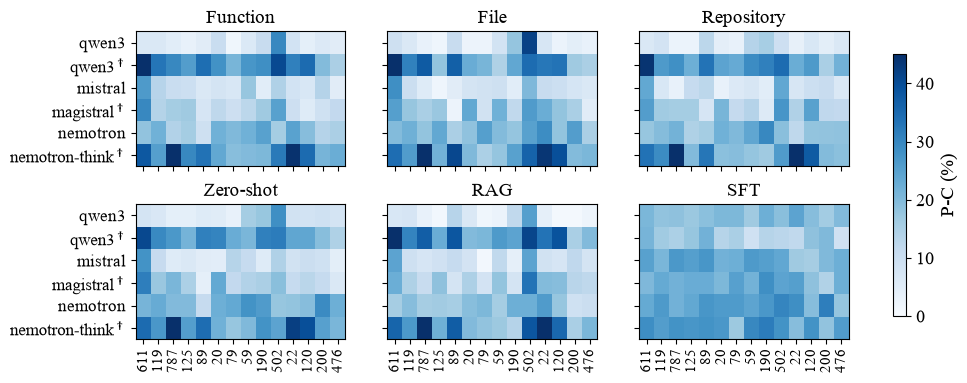

In [9]:
# 7b. rq3cwe heatmaps (Blues, larger fonts)
fig,axes=plt.subplots(2,3,figsize=(11.5,4.0),sharey=True)
def short(m):
    s=m.replace("-small","").replace("-nano","").split(":")[0]
    s=s.replace("qwen3-30b-instruct","qwen3").replace("qwen3-30b-thinking","qwen3")
    return s + ("$^\\dagger$" if m in REASONING else "")
SNAME={"function":"Function","file":"File","repository":"Repository"}
TNAME={"zero":"Zero-shot","rag":"RAG","sft":"SFT"}
for ax,(ttl,H) in zip(axes[0],[(SNAME[s],heat_scope[s]) for s in SCOPES]):
    im=ax.imshow(H.values.astype(float)*100,cmap="Blues",aspect="auto",vmin=0,vmax=45)
    ax.set_title(ttl,fontsize=14)
    ax.set_xticks(range(len(CWES))); ax.set_xticklabels([])   # labels only on bottom row
for ax,(ttl,H) in zip(axes[1],[(TNAME[s],heat_strat[s]) for s in STRATS]):
    im=ax.imshow(H.values.astype(float)*100,cmap="Blues",aspect="auto",vmin=0,vmax=45)
    ax.set_title(ttl,fontsize=14)
    ax.set_xticks(range(len(CWES))); ax.set_xticklabels([c.replace("CWE-","") for c in CWES],fontsize=11,rotation=90)
for row in axes:
    row[0].set_yticks(range(len(MODELS)))
    row[0].set_yticklabels([short(m) for m in MODELS],fontsize=12)
fig.subplots_adjust(hspace=0.28)
cb=fig.colorbar(im,ax=axes,shrink=0.85); cb.set_label("P-C (%)",fontsize=14)
fig.savefig(FIGDIR/"results_rq3cwe.pdf",bbox_inches="tight"); print("saved results_rq3cwe.pdf")

saved results_rq3lang.pdf


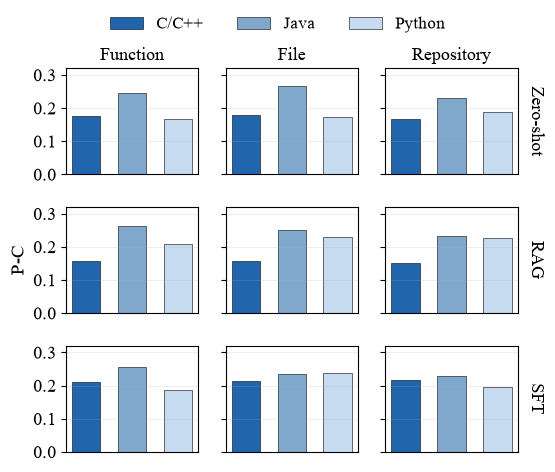

In [10]:
# 7c. rq3lang — 3x3 grid: rows=strategy, cols=scope; bars=language P-C
LANG_C=dict(zip(langs,BLUES3))
SNAME={"function":"Function","file":"File","repository":"Repository"}
TNAME={"zero":"Zero-shot","rag":"RAG","sft":"SFT"}
fig,axes=plt.subplots(3,3,figsize=(5.8,4.6),sharey=True,sharex=True)
for r,s in enumerate(STRATS):
    for cix,sc in enumerate(SCOPES):
        ax=axes[r][cix]
        vs=[lang_pc[(L,sc,s)] for L in langs]
        ax.bar(range(3),vs,0.62,color=BLUES3,edgecolor="k",linewidth=0.4)
        ax.set_ylim(0,0.32); ax.set_yticks([0,0.1,0.2,0.3])
        ax.set_xticks([]); ax.grid(axis="y",alpha=0.3,lw=0.5)
        if r==0: ax.set_title(SNAME[sc],fontsize=13)
        if cix==2:
            ax.text(1.08,0.5,TNAME[s],transform=ax.transAxes,rotation=270,
                    va="center",ha="left",fontsize=13)
axes[1][0].set_ylabel("P-C",fontsize=14)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor=LANG_C[L],edgecolor="k",linewidth=0.4,label=L) for L in langs],
           ncol=3,loc="upper center",bbox_to_anchor=(0.5,1.05),frameon=False,fontsize=12)
fig.tight_layout()
fig.savefig(FIGDIR/"results_rq3lang.pdf",bbox_inches="tight"); print("saved results_rq3lang.pdf")


Function    before mean=2311 med=1244 | after mean=2311 med=1244
File        before mean=10059 med=5791 | after mean=10059 med=5791
Repository  before mean=28010 med=16047 | after mean=5161 med=2857
saved token_statistics.png


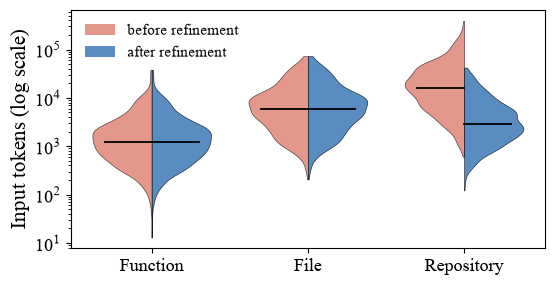

In [11]:
# 7e. token statistics: split violins — before (left, salmon) vs after (right, blue)
import tiktoken
from scipy.stats import gaussian_kde
ENC=tiktoken.get_encoding("cl100k_base")
def ntok(s): return len(ENC.encode(s,disallowed_special=()))
test=[json.loads(l) for l in open(f"data/{BENCH}.jsonl")]
func=[ntok(r["function"]) for r in test]
file_=[ntok(r["file"]) for r in test]
repo_after=[ntok(r["function"])+sum(ntok(c.get("function") or "") for c in
      ((r.get("repository") or {}).get("callee") or [])+((r.get("repository") or {}).get("caller") or []))
      for r in test]
recs=[json.loads(l) for l in open("data/token_before_after.jsonl")]
repo_before=[x["repo_before_tokens"] for x in recs if x.get("repo_before_tokens")]
pairs=[("Function",func,func),("File",file_,file_),("Repository",repo_before,repo_after)]

def half_violin(ax,x,vals,side,color,alpha):
    lv=np.log10(vals); kde=gaussian_kde(lv)
    ys=np.linspace(lv.min(),lv.max(),200); ds=kde(ys); ds=0.38*ds/ds.max()
    if side=="left":
        ax.fill_betweenx(10**ys,x-ds,x,facecolor=color,alpha=alpha,edgecolor="k",linewidth=0.5)
    else:
        ax.fill_betweenx(10**ys,x,x+ds,facecolor=color,alpha=alpha,edgecolor="k",linewidth=0.5)
    med=np.median(vals)
    xs=(x-0.30,x) if side=="left" else (x,x+0.30)
    ax.plot(xs,[med,med],color="k",lw=1.3)

fig,ax=plt.subplots(figsize=(5.8,3.1))
for i,(lab,bef,aft) in enumerate(pairs,1):
    bef=np.asarray(bef); aft=np.asarray(aft)
    half_violin(ax,i,bef,"left",C_PV,0.65)
    half_violin(ax,i,aft,"right",C_PC,0.75)
    print(f"{lab:<11} before mean={bef.mean():.0f} med={np.median(bef):.0f} | after mean={aft.mean():.0f} med={np.median(aft):.0f}")
ax.set_yscale("log"); ax.set_xticks([1,2,3]); ax.set_xticklabels([p[0] for p in pairs])
ax.set_ylabel("Input tokens (log scale)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=C_PV,alpha=0.65,label="before refinement"),
                   Patch(facecolor=C_PC,alpha=0.75,label="after refinement")],
          loc="upper left",frameon=False,fontsize=11)
fig.tight_layout(); fig.savefig("paper/figures/token_statistics.png",dpi=200)
print("saved token_statistics.png")

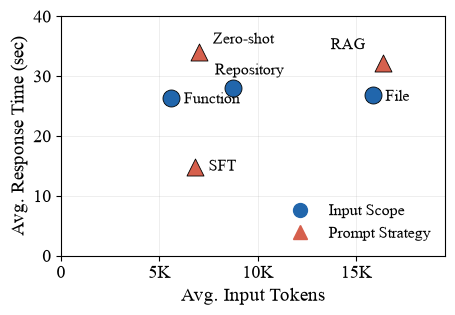

In [12]:
# Fig 3 (fig:rq2eff) — efficiency plane: each scope (strategies pooled) and each strategy (scopes pooled) as one point
import numpy as np
d=df.dropna(subset=["tokens"])
pts={}
for sc,lab in [("function","Function"),("file","File"),("repository","Repository")]:
    sub=d[d.scope==sc]; pts[lab]=("scope",sub["tokens"].mean(),sub["time(s)"].mean())
for st,lab in [("zero","Zero-shot"),("rag","RAG"),("sft","SFT")]:
    sub=d[d.prompts==st]; pts[lab]=("strat",sub["tokens"].mean(),sub["time(s)"].mean())
C_SC,C_ST="#2166ac","#d6604d"
fig,ax=plt.subplots(figsize=(4.8,3.4))
off={"Function":(9,-4),"File":(9,-4),"Repository":(-13,10),"Zero-shot":(10,6),"RAG":(-38,10),"SFT":(10,-3)}
for k,(g,x,y) in pts.items():
    c,m=(C_SC,"o") if g=="scope" else (C_ST,"^")
    ax.scatter(x,y,s=150,c=c,marker=m,edgecolors="k",linewidths=0.6,zorder=3)
    ax.annotate(k,(x,y),textcoords="offset points",xytext=off[k],fontsize=11.5)
ax.set_xlabel("Avg. Input Tokens",fontsize=14)
ax.set_ylabel("Avg. Response Time (sec)",fontsize=14)
ax.set_xlim(0,19500); ax.set_ylim(0,40)
ax.set_xticks([0,5000,10000,15000]); ax.set_xticklabels(["0","5K","10K","15K"],fontsize=13)
ax.tick_params(labelsize=13); ax.grid(alpha=0.3,lw=0.5)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([],[],marker="o",ls="",color=C_SC,ms=10,label="Input Scope"),
                   Line2D([],[],marker="^",ls="",color=C_ST,ms=10,label="Prompt Strategy")],
          loc="lower right",fontsize=11.5,frameon=False)
fig.tight_layout()
fig.savefig("paper/figures/results_rq2eff.pdf",bbox_inches="tight",pad_inches=0.06)
plt.show()